In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("recruitment_data.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (1500, 11)

First 5 Rows:
   Age  Gender  EducationLevel  ExperienceYears  PreviousCompanies  \
0   26       1               2                0                  3   
1   39       1               4               12                  3   
2   48       0               2                3                  2   
3   34       1               2                5                  2   
4   30       0               1                6                  1   

   DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  \
0            26.783828              48          78                91   
1            25.862694              35          68                80   
2             9.920805              20          67                13   
3             6.407751              36          27                70   
4            43.105343              23          52                85   

   RecruitmentStrategy  HiringDecision  
0                    1               1  
1                    2 

In [3]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 KB

Missing Values:
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScor

In [4]:
X = df.drop("HiringDecision", axis=1)

y = df["HiringDecision"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable: HiringDecision")

Input Features:
['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy']

Target Variable: HiringDecision


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("====================================")
print("TRAIN-TEST SPLIT")
print("====================================")

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

TRAIN-TEST SPLIT
Training Data: (1200, 10)
Testing Data: (300, 10)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [7]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


In [8]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [9]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

print("Naive Bayes training completed.")

Naive Bayes training completed.


In [10]:
print("====================================")
print("DECISION TREE - CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        dt_pred,
        target_names=["Not Hired", "Hired"],
        zero_division=0
    )
)

DECISION TREE - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Hired       0.87      0.89      0.88       207
       Hired       0.74      0.70      0.72        93

    accuracy                           0.83       300
   macro avg       0.80      0.79      0.80       300
weighted avg       0.83      0.83      0.83       300



In [11]:
print("====================================")
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=["Not Hired", "Hired"],
        zero_division=0
    )
)

LOGISTIC REGRESSION - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Hired       0.87      0.93      0.90       207
       Hired       0.81      0.70      0.75        93

    accuracy                           0.86       300
   macro avg       0.84      0.81      0.83       300
weighted avg       0.85      0.86      0.85       300



In [12]:
print("====================================")
print("NAIVE BAYES - CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["Not Hired", "Hired"],
        zero_division=0
    )
)

NAIVE BAYES - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Hired       0.85      0.94      0.89       207
       Hired       0.82      0.63      0.72        93

    accuracy                           0.84       300
   macro avg       0.84      0.79      0.80       300
weighted avg       0.84      0.84      0.84       300



In [13]:
results = pd.DataFrame({

    "Algorithm": [
        "Decision Tree",
        "Logistic Regression",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred)
    ],

    "Precision": [
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, lr_pred, zero_division=0),
        precision_score(y_test, nb_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, lr_pred, zero_division=0),
        recall_score(y_test, nb_pred, zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, lr_pred, zero_division=0),
        f1_score(y_test, nb_pred, zero_division=0)
    ]
})

print("====================================")
print("MODEL PERFORMANCE COMPARISON")
print("====================================")

print(results.round(3))

MODEL PERFORMANCE COMPARISON
             Algorithm  Accuracy  Precision  Recall  F1 Score
0        Decision Tree     0.830      0.739   0.699     0.718
1  Logistic Regression     0.857      0.812   0.699     0.751
2          Naive Bayes     0.843      0.819   0.634     0.715


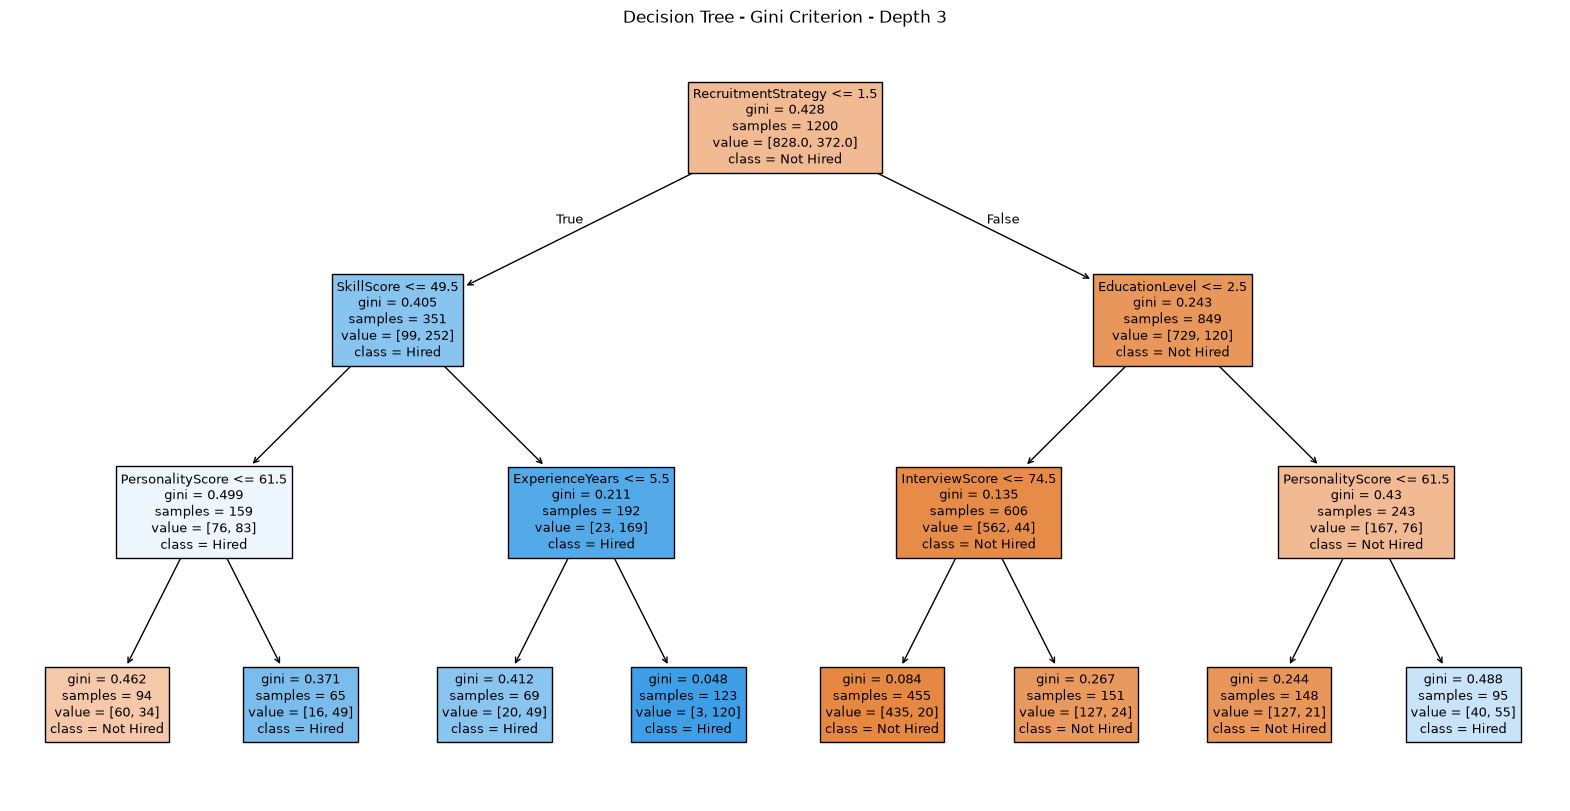

In [14]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Not Hired", "Hired"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree - Gini Criterion - Depth 3")

plt.show()

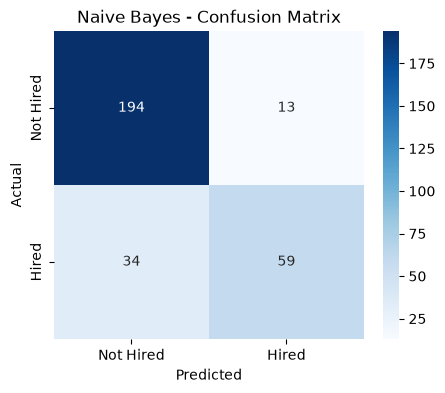

In [15]:
cm = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Hired", "Hired"],
    yticklabels=["Not Hired", "Hired"]
)

plt.title("Naive Bayes - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

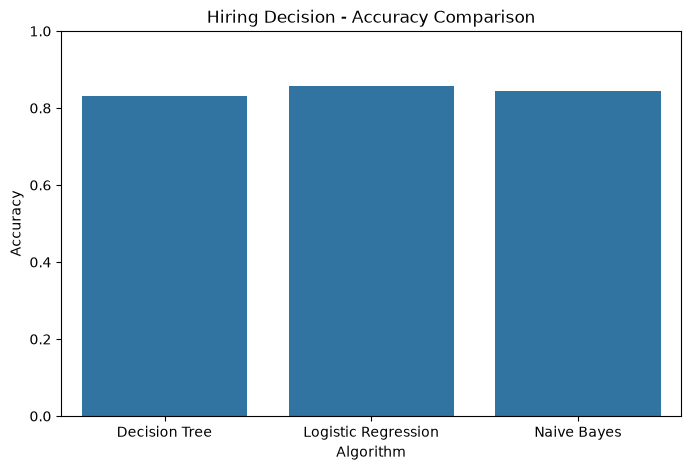

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Algorithm",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title("Hiring Decision - Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [17]:
best = results.loc[
    results["F1 Score"].idxmax()
]

print("====================================")
print("BEST PERFORMING ALGORITHM")
print("====================================")

print("Best Algorithm:", best["Algorithm"])

print(
    "Accuracy:",
    round(best["Accuracy"] * 100, 2),
    "%"
)

print(
    "Precision:",
    round(best["Precision"], 3)
)

print(
    "Recall:",
    round(best["Recall"], 3)
)

print(
    "F1 Score:",
    round(best["F1 Score"], 3)
)

BEST PERFORMING ALGORITHM
Best Algorithm: Logistic Regression
Accuracy: 85.67 %
Precision: 0.812
Recall: 0.699
F1 Score: 0.751
